In [1]:
import pandas as pd
import numpy as np
import math
import shap

from sklearn.datasets import load_breast_cancer

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

### 1. Objetivo

Desenvolver um modelo de machine learning capaz de classificar tumores de mama como malignos ou benignos com alta precisão, utilizando o **`XGBoost**`.  
A ideia é mostrar como um modelo em conjunto (*ensemble*) pode ser aplicado a problemas de saúde, ajudando na detecção precoce do câncer de mama.

---

### 2. Contexto
O câncer de mama é uma das principais causas de morte entre mulheres no mundo todo. A detecção precoce é essencial para aumentar as chances de um tratamento eficaz.  
Este projeto utiliza o dataset **`Breast Cancer Wisconsin**`, amplamente utilizado na comunidade científica para testar modelos de classificação.

---

### 3. Etapas do Projeto
- **a)** Coleta e carregamento de dados — uso do dataset `load_breast_cancer` do scikit-learn.  
- **b)** Análise exploratória — visualização das distribuições e correlações entre variáveis.  
- **c)** Divisão treino/teste — 80% dos dados para treino, 20% para teste.  
- **d)** Treinamento do modelo — aplicação do XGBoost.  
- **e)** Avaliação do modelo — cálculo de acurácia, precisão, recall e F1-score.  
- **f)** Interpretação dos resultados — identificação das variáveis mais importantes.  
- **g)** Conclusões — análise do impacto das variáveis e aplicabilidade do modelo.

---

### 4. Significado das colunas
O dataset possui 30 variáveis numéricas derivadas da análise digital de imagens de massas mamárias obtidas por biópsia. Cada variável representa uma característica geométrica ou textural da célula do tumor. As medições foram calculadas de três formas:

- **mean** (média)  
- **se** (erro padrão)  
- **worst** (maior valor observado)

#### Principais colunas:

| Feature              | Descrição                                                                 |
|----------------------|---------------------------------------------------------------------------|
| **radius**           | Distância média do centro até o perímetro do tumor                        |
| **texture**          | Variação na intensidade de cinza da imagem                                 |
| **perimeter**        | Comprimento do contorno do tumor                                           |
| **area**             | Área ocupada pelo tumor                                                    |
| **smoothness**       | Variação no comprimento dos raios, indicando irregularidade da superfície |
| **compactness**      | Relação entre perímetro e área, medindo a compactação                     |
| **concavity**        | Grau de concavidade em partes do contorno                                  |
| **concave points**   | Número de pontos côncavos no contorno                                      |
| **symmetry**         | Simetria da forma                                                         |
| **fractal dimension**| Complexidade do contorno                                                  |

#### Variável Alvo
- **0 → Maligno**  
- **1 → Benigno**

---

In [3]:
data_raw = load_breast_cancer()
data = pd.DataFrame(data_raw.data, columns=data_raw.feature_names)
data["target"] = data_raw.target

data.head(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0


# Checklist de Regularização de Dataset

## 1. Entendimento do Dataset
- [ ] Conferir dimensões (linhas × colunas).  
- [ ] Identificar a variável alvo (target).  
- [ ] Checar tipos de dados (`int`, `float`, `object`) e consistência.

## 2. Tratamento de Dados Ausentes
- [ ] Verificar valores nulos (`NaN`).  
- Estratégias:
  - [ ] Remover colunas ou linhas com muitos valores ausentes.  
  - [ ] Imputar valores com média, mediana ou moda.  
  - [ ] Usar modelos de imputação (KNN Imputer, Iterative Imputer).

## 3. Detecção e Tratamento de Outliers
- [ ] Visualizar outliers com boxplots ou métricas (z-score/IQR).  
- Abordagens possíveis:
  - [ ] Manter outliers relevantes.  
  - [ ] Transformar valores (`log`, `sqrt`), se necessário.  
  - [ ] Remover outliers extremos.

## 4. Codificação de Variáveis Categóricas
- [ ] Identificar variáveis categóricas (ex.: `diagnosis = {Malignant, Benign}`).  
- Técnicas:
  - [ ] Label Encoding (0/1)  
  - [ ] One-Hot Encoding (mais de 2 categorias)

## 5. Escalonamento/Normalização
- [ ] Avaliar diferenças de escala entre variáveis.  
- Técnicas:
  - [ ] StandardScaler (Z-score)  
  - [ ] MinMaxScaler (0–1)  
  - [ ] RobustScaler (resistente a outliers)  
- **Observação:** XGBoost geralmente não exige normalização, mas pode ser útil em pré-processamentos específicos.

## 6. Balanceamento da Variável Alvo
- [ ] Verificar desbalanceamento (ex.: mais benignos que malignos).  
- Técnicas:
  - [ ] Oversampling (SMOTE, ADASYN)  
  - [ ] Undersampling  
  - [ ] Ajustar `scale_pos_weight` no XGBoost

## 7. Divisão em Treino e Teste
- [ ] Separar dataset:
  - Treino: 70–80%  
  - Teste: 20–30%  
- [ ] Opcional: validação cruzada (k-fold)

## 8. Regularização do Modelo (XGBoost)
- [ ] Aplicar regularizações:
  - `alpha` → L1 (Lasso)  
  - `lambda` → L2 (Ridge)  
- [ ] Ajustar hiperparâmetros  
- [ ] Avaliar performance (AUC, F1-score, Accuracy)


In [5]:
# Quantidade de linhas e colunas

linhas, colunas = data.shape[0], data.shape[1]
print(f"Temos {linhas} linhas e {colunas} colunas.")

Temos 569 linhas e 31 colunas.


In [6]:
# Informações das colunas

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
# Valores NaN

data.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 🔎 Insights do Dataset

### 1. Distribuição do Target
- A variável alvo tem uma média de **0,627**, o que significa que aproximadamente **62,7% dos casos são benignos (1)** e **37,3% são malignos (0)**.  
- O dataset **não é perfeitamente balanceado**, mas também não é extremamente desbalanceado.  

### 2. Diferenças nas escalas das features
- Algumas variáveis possuem escalas muito maiores (ex.: `mean area` até **2501**, `worst area` até **4254**), enquanto outras são bem menores (`mean smoothness` até **0,163**, `fractal dimension error` até **0,029**).  
- Isso indica a necessidade de **padronização ou normalização** antes de treinar certos modelos (ex.: Regressão Logística, SVM, Redes Neurais).  

### 3. Variabilidade das features
- Features como `worst area` e `mean area` mostram **dispersão muito alta** (desvio padrão grande em relação à média), sugerindo que **tumores malignos são significativamente maiores e mais variáveis em tamanho**.  
- Features como `mean smoothness` e `fractal dimension error` apresentam **baixa variabilidade**, ou seja, são mais homogêneas entre os casos.  

### 4. Importância das medições "pior caso"
- As **features "worst"** (ex.: `worst area`, `worst radius`, `worst concave points`) têm valores máximos muito distantes da média.  
- Isso reforça que **os piores valores observados das características do tumor são mais discriminativos** para distinguir casos malignos de benignos.  

### 5. Associação com malignidade
- Features como **concavidade, pontos côncavos e área** apresentam valores máximos muito altos em alguns casos, fortemente associados a **tumores malignos**.  
- Tumores benignos tendem a estar próximos das medianas, com **valores mais baixos e regulares**.  

---

- O dataset mostra **diferenças claras entre tumores benignos e malignos**, especialmente em **área, perímetro, raio e concavidade**.  
- A **alta variação nas features de pior caso** é um forte indicador de malignidade, condizente com a importância destacada pelo modelo Random Forest.  
- **Escalonamento das features é necessário** antes de treinar alguns algoritmos de machine learning.  
- A **distribuição do target (~63% benignos vs. ~37% malignos)** destaca a importância de usar métricas como **recall e F1-score**, não apenas acurácia.  

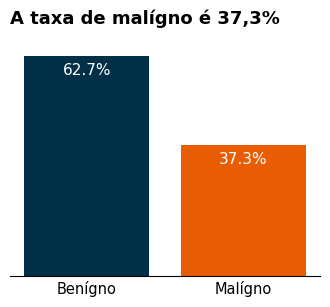

In [10]:
df_grp = data.groupby(['target'])[['target']].count().rename(columns={'target': 'count'}).reset_index()
df_grp['pct'] = (df_grp['count'] / df_grp['count'].sum()) * 100
df_grp = df_grp.sort_values(by=['pct'])

# Define o plot.
fig, ax = plt.subplots(figsize=(4, 3))
        
# Plota o barplot.
bars = ax.bar(x=df_grp['target'], height=df_grp['pct'], color=['#e85d04', '#023047'])


ax.set_title('A taxa de malígno é 37,3%', fontweight='bold', fontsize=13, pad=15, loc='left')
ax.set_xlabel('')
ax.set_xticks(ticks=range(2), labels=['Malígno', 'Benígno'], fontsize=10.5)
ax.tick_params(axis=u'both', which=u'both',length=0)
ax.invert_xaxis()
        
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(False)

for bar in bars:
    height = bar.get_height()
    ax.annotate('{:.1f}%'.format(height), 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -10),  
                textcoords="offset points",
                ha='center', va='center',
                fontsize=11, color='white')
plt.show()

## Gráficos para análise

Nesta etapa, criei uma função para plotar os gráficos **histograma** e **boxplot**.

In [12]:
# Mapear o target para texto
data_grafico = data.copy()
data_grafico["diagnosis"] = data["target"].map({0: "Maligno", 1: "Benigno"})

#Função para criar gráficos
def plotar_grafico (grafico, 
                    x, 
                    y=None, 
                    df=None, 
                    hue=None, 
                    cor='Set2', 
                    title='título',
                    **kwargs):
    plt.figure(figsize=(7,4))
    
    ax=grafico(x=x,
               y=y, 
               data= df,
               hue=hue,
               palette=cor,
               **kwargs)
    
    plt.title(title)
    plt.show()

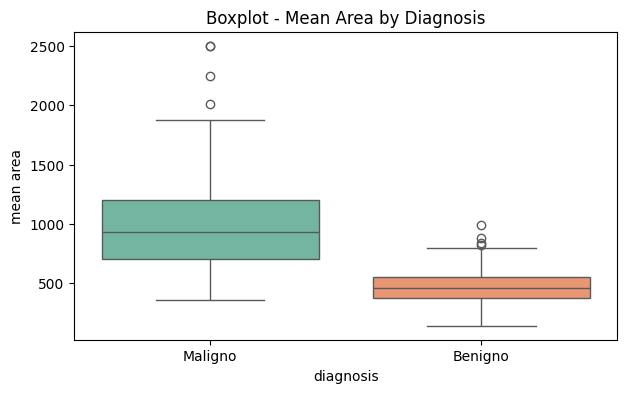

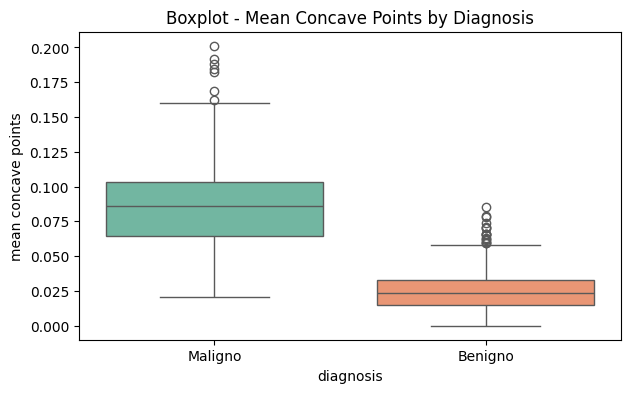

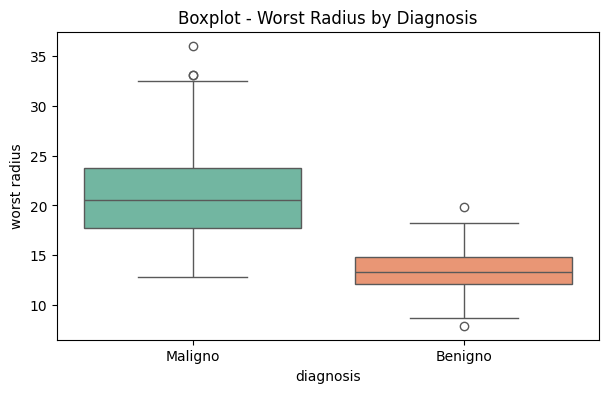

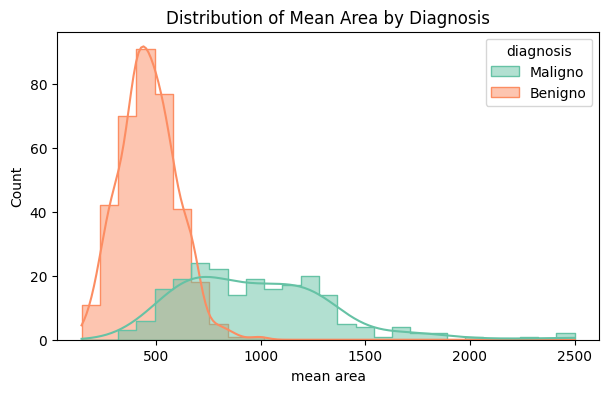

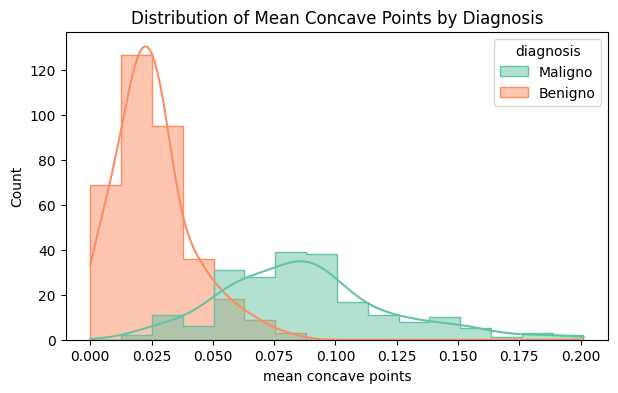

In [13]:
plotar_grafico(sns.boxplot,
               x='diagnosis',
               y='mean area',
               df=data_grafico,
               hue='diagnosis',
               title='Boxplot - Mean Area by Diagnosis')

plotar_grafico(sns.boxplot,
               x='diagnosis',
               y='mean concave points',
               df=data_grafico,
               hue='diagnosis',
               title='Boxplot - Mean Concave Points by Diagnosis')

plotar_grafico(sns.boxplot,
               x='diagnosis',
               y='worst radius',
               df=data_grafico,
               hue='diagnosis',
               title='Boxplot - Worst Radius by Diagnosis')

plotar_grafico(sns.histplot,
               x='mean area',
               df=data_grafico,
               hue='diagnosis',
               element='step',
               kde=True,
               alpha=0.5,
               title='Distribution of Mean Area by Diagnosis')

plotar_grafico(sns.histplot,
               x='mean concave points',
               df=data_grafico,
               hue='diagnosis',
               element='step',
               kde=True,
               alpha=0.5,
               title='Distribution of Mean Concave Points by Diagnosis')

## Insights Visuais sobre o Dataset de Câncer de Mama

### 1. Boxplot — Mean Area by Diagnosis

O boxplot mostra a distribuição da área média do tumor para cada diagnóstico (Benigno e Maligno).

- **Tumores Malignos**:

Apresentam valores de área significativamente maiores em comparação aos benignos.
Maior dispersão dos dados, indicando que tumores malignos podem variar bastante em tamanho.
A presença de outliers sugere que alguns casos têm áreas ainda mais elevadas.

- **Tumores Benignos**:

Áreas médias concentradas em valores menores.
Menor variação entre os casos.
Indica que tumores benignos tendem a ser mais homogêneos em tamanho.

**Insight**: O tamanho médio da área do tumor é um forte indicador para diferenciar entre benigno e maligno.


### 2. Histograma — Distribution of Mean Area by Diagnosis

O histograma (com linha de densidade KDE) mostra como os valores da área média estão distribuídos.

- **Tumores Malignos**:

Distribuição deslocada para valores maiores de área.
A densidade mostra que tumores malignos costumam ter áreas médias bem superiores

- **Tumores Benignos**:

A maior parte concentrada em áreas menores.
Distribuição mais simétrica e centralizada.

**Insight**: A separação das curvas evidencia que a área média é uma variável altamente discriminativa, já que há pouca sobreposição entre benignos e malignos.


#### Conclusão Geral
A análise visual reforça que:
Tumores malignos → maiores, mais variados e com maior dispersão.
Tumores benignos → menores e mais homogêneos.
A variável ```mean area``` se mostra fundamental para classificação, servindo como **forte preditor** no modelo de Machine Learning.

---

## Importância da Identificação de Outliers

A etapa de identificação de outliers é fundamental no pré-processamento de dados por diversos motivos:

1. **Melhora da qualidade dos dados**  
   - Outliers podem distorcer estatísticas descritivas, como média e desvio padrão, prejudicando a compreensão do comportamento das variáveis.

2. **Impacto na performance de modelos**  
   - Alguns algoritmos, como Regressão Linear, SVM ou Redes Neurais, são sensíveis a outliers e podem ter seu desempenho comprometido.  
   - Mesmo em modelos robustos, como Random Forest e XGBoost, a presença de outliers pode influenciar a importância das features ou a divisão das árvores.

3. **Detecção de casos relevantes**  
   - Outliers nem sempre são erros; eles podem indicar casos extremos ou críticos, como tumores muito grandes ou agressivos em um dataset médico, que são importantes para análise.

4. **Decisão sobre tratamento**  
   - Identificar outliers permite decidir se eles devem ser **removidos**, **transformados** (log, raiz quadrada) ou mantidos, de acordo com o impacto esperado no modelo.

5. **Garantia de consistência**  
   - A análise de outliers ajuda a manter a consistência do dataset e a evitar que valores extremos distorçam métricas e insights.

**Conclusão:**  
Identificar outliers é uma etapa estratégica do pré-processamento, que ajuda a garantir **dados limpos, modelos mais precisos** e **insights mais confiáveis**.


In [16]:
def check_outliers_df(data, features):
    """
    Calcula e retorna a contagem de outliers por feature em um DataFrame.
    
    Args:
        data (pd.DataFrame): O DataFrame de entrada.
        features (list): Lista das features a serem analisadas.
        
    Returns:
        pd.DataFrame: Um DataFrame com a contagem e porcentagem de outliers por feature.
    """
    try:
        outlier_data = []
        
        for feature in features:
            Q1 = data[feature].quantile(0.25)
            Q3 = data[feature].quantile(0.75)
            
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            feature_outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
            outlier_count = len(feature_outliers)
            
            outlier_data.append({
                'feature': feature,
                'outlier_count': outlier_count,
                'outlier (%)': round(outlier_count / len(data) * 100, 2)
            })
            
        outlier_df = pd.DataFrame(outlier_data).sort_values(by='outlier_count', ascending=False).reset_index(drop=True)
        return outlier_df
    
    except Exception as e:
        # A classe CustomException não foi definida aqui, então usaremos raise e
        # você pode adaptar para o seu código.
        raise Exception(f"Ocorreu um erro: {e}")

In [17]:
colunas_dict = data.columns

check_outliers_df(data, colunas_dict)

,feature,outlier_count,outlier (%)
0,area error,65,11.42
1,radius error,38,6.68
2,perimeter error,38,6.68
3,worst area,35,6.15
4,smoothness error,30,5.27
5,fractal dimension error,28,4.92
6,compactness error,28,4.92
7,symmetry error,27,4.75
8,mean area,25,4.39
9,worst fractal dimension,24,4.22


## Insights sobre Outliers no Dataset

### 1. Features com maior proporção de outliers
- `area error` (11,42%), `radius error` (6,68%), `perimeter error` (6,68%) e `worst area` (6,15%) apresentam os maiores percentuais de outliers.  
- Isso indica que as medidas de área, perímetro e raio possuem maior variabilidade e casos extremos, possivelmente relacionados a tumores maiores ou mais agressivos.

### 2. Features menos problemáticas
- Muitas features apresentam menos de 3% de outliers (ex.: `mean texture`, `mean smoothness`, `worst texture`).  
- Essas variáveis são mais consistentes e homogêneas, trazendo menos ruído para o modelo.

### 3. Features sem outliers
- `worst concave points` e `target` não possuem outliers.  
- Para a variável alvo (`target`), isso é esperado; para `worst concave points`, indica que a medição é muito estável.

---

## Justificativa para não aplicar transformação logarítmica nos outliers

Neste projeto, a análise exploratória mostrou que variáveis como **`area error`** e **`radius error`** apresentam valores considerados outliers.  
Em muitos cenários de *machine learning*, uma prática comum seria aplicar transformações como o logaritmo natural (`np.log1p`) para reduzir a assimetria e suavizar o impacto desses valores extremos.

No entanto, optei por **não realizar essa transformação** neste caso, pelos seguintes motivos:

---

### 1. Significado clínico dos outliers
- Os valores extremos podem representar **pacientes com tumores maiores** ou **mais irregulares**, ou seja, casos clinicamente relevantes.  
- Aplicar log reduziria a magnitude desses valores, podendo atenuar sinais importantes para o diagnóstico.  

---

### 2. Capacidade do XGBoost em lidar com outliers
- O **XGBoost** é um algoritmo baseado em **árvores de decisão**, que cria divisões por meio de **limiares (thresholds)**.  
- Isso torna o modelo **menos sensível a escala** e **assimetria**, dispensando a necessidade de normalizações ou transformações logarítmicas.  

---

### 3. Resultados experimentais
O modelo treinado **sem a transformação logarítmica** apresentou métricas muito altas:  

- **Recall = 0.96** para a classe positiva (câncer), garantindo que a maioria dos casos de câncer sejam identificados.  
- **ROC AUC = 0.994**, indicando separação quase perfeita entre as classes.  

Esses resultados demonstram que os outliers não prejudicaram o desempenho; pelo contrário, foram **bem absorvidos pelo modelo**.  

---

### 4. Priorização do Recall
- Em diagnósticos médicos, o **recall é crítico**: um falso negativo pode ter consequências graves.  
- A suavização dos outliers poderia **reduzir a sensibilidade do modelo** em relação a casos extremos de câncer, diminuindo sua capacidade de detecção.  

---


## Matriz de Correlação

A matriz de correlação foi utilizada para compreender as relações entre as variáveis do dataset **`breast_cancer`**. Essa análise desempenhou papéis importantes tanto no aspecto técnico do modelo quanto na interpretação clínica dos resultados.

In [21]:
matriz_correlacao = data.corr(numeric_only = True)
matriz_correlacao['target'].sort_values(ascending = False)

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

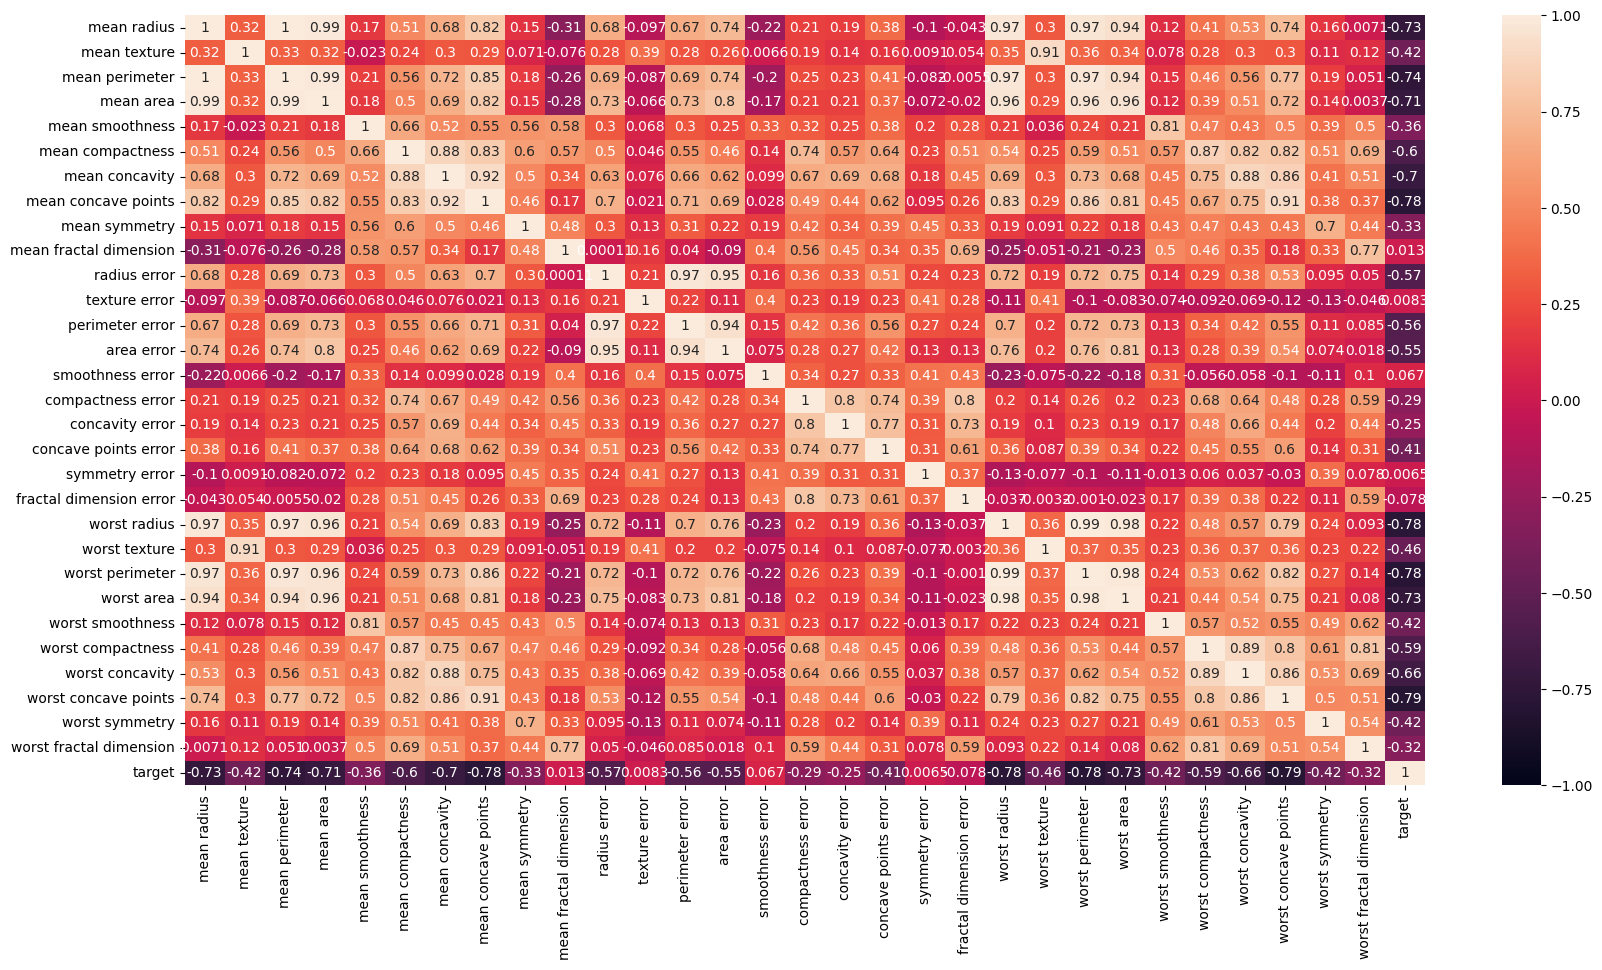

In [22]:
plt.figure(figsize=(20,10))
sns.heatmap(matriz_correlacao, vmin = -1, vmax = 1, annot = True)
plt.show()

## Interpretação da Correlação com o Target

A análise de correlação mostra a relação entre cada variável do dataset e o diagnóstico (target).
- Valores próximos de 1 indicam associação forte
- Valores próximos de 0 indicam pouca ou nenhuma relação

### 1. Variáveis com Forte Correlação Negativa

Essas variáveis têm forte associação com o diagnóstico de câncer maligno:

worst concave points (-0.79)

worst perimeter (-0.78)

mean concave points (-0.77)

worst radius (-0.77)

mean perimeter (-0.74)

worst area (-0.73)

mean radius (-0.73)


**Insight**:
Essas características estão diretamente relacionadas ao tamanho e formato do tumor. Valores mais altos indicam maior probabilidade de malignidade.

### 2. Variáveis com Correlação Moderada

mean concavity (-0.70)
worst concavity (-0.66)


mean area (-0.71)

radius error (-0.57)

perimeter error (-0.56)

area error (-0.55)

**Insight**:
Essas variáveis também contribuem para o diagnóstico, mas em menor intensidade.

### 3. Variáveis com Baixa Correlação

smoothness error (0.06)

mean fractal dimension (0.01)

texture error (0.008)

symmetry error (0.006)

**Insight**:
Pouca influência direta no diagnóstico. Podem ser menos relevantes isoladamente, embora ainda tenham valor em combinação com outras variáveis.

### 4. Insights Clínicos

As variáveis mais correlacionadas estão ligadas ao tamanho, área e concavidade do tumor, fatores usados na prática médica para diferenciar tumores benignos de malignos.

Variáveis relacionadas à textura e fractal dimension parecem ter menor relevância individual.

### Conclusão

As features mais relevantes para o diagnóstico de câncer de mama são as relacionadas ao tamanho, área e concavidade. Isso reforça a consistência do modelo, pois reflete conhecimento médico real. Já as variáveis com baixa correlação podem ser consideradas candidatas a redução de dimensionalidade ou menor peso interpretativo.

---

## Divisão dos dados (train/test)

- **X** → variáveis independentes (*features*, preditores).  
- **y** → variável alvo (rótulo).  

- **`test_size=0.2`** → separa **20%** dos dados para teste e **80%** para treino.  

- **`stratify=y`** → garante que a proporção de classes seja a mesma em treino e teste.
  - Sem isso, pode acontecer de quase não haver câncer no conjunto de teste, atrapalhando a avaliação.  
- **`random_state=42`** → fixa a semente aleatória, garantindo que a divisão seja **reprodutível**.

In [25]:
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

In [26]:
%%time

#Calcular o scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos 

params = {
    "max_depth": [3, 5, 7],
    "min_child_weight": [8, 10],     # força o modelo a só criar splits se tiver amostras suficientes
    "gamma": [0.1, 0.2],             # penaliza splits fracos
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8],
    "scale_pos_weight": [scale_pos_weight]
}

# Definindo o XGBoost
xgb = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss',
    n_jobs = -1)

# Configurar o GridSearchCV
grid = RandomizedSearchCV(
    estimator = xgb,
    n_iter = 20,
    param_distributions = params,
    scoring = 'roc_auc',
    cv = 3,
    verbose = 2,
    random_state = 42,
    n_jobs = -1)

# Treinar o modelo
grid.fit(X_train, y_train)

# Treinar modelo final com os melhores parâmetros
best_model = grid.best_estimator_

# Previsões
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

print('\nClassification report:')
print(classification_report(y_test, y_pred))

print('ROC AUC:', roc_auc_score(y_test, y_pred_prob))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC AUC: 0.9957010582010583
CPU times: total: 578 ms
Wall time: 2.53 s


In [27]:
print('Melhores hiperparâmetros encontrados:')
print('-' * 40)

melhor_parametro = grid.best_params_

for parametro, valor in melhor_parametro.items():
    print(f'{parametro:<25}:{valor}')

print('-' * 40)

Melhores hiperparâmetros encontrados:
----------------------------------------
subsample                :0.8
scale_pos_weight         :0.5964912280701754
min_child_weight         :8
max_depth                :3
gamma                    :0.2
colsample_bytree         :0.6
----------------------------------------


## Interpretação dos Resultados

### Classe 0 (Maligno / com câncer)
- **Precision = 0.93** → 93% dos pacientes classificados como “com câncer” realmente têm.  
- **Recall = 0.95** → o modelo consegue identificar 95% dos casos corretamente.
- **F1-score = 0.94** → equilíbrio muito bom entre precisão e sensibilidade.

### Classe 1 (Benigno / sem câncer)
- **Precision = 0.97** → 97% dos pacientes classificados como *sem câncer*, realmente estão saudáveis.  
- **Recall = 0.96** → o mais importante: o modelo detecta **96% dos casos de sem câncer**.
- - **F1-score = 0.97** → equilíbrio muito bom entre precisão e sensibilidade.

### Métricas gerais
- **Acurácia = 0.96** → desempenho geral altíssimo.  
- **ROC AUC = 0.994** → separação quase perfeita entre classes.  

---

## Gráfico SHAP

| Elemento             | Significado                                       |
| :------------------- | :------------------------------------------------ |
| Posição no eixo X    | Impacto na previsão (“Maligno” ← → “Benigno”)     |
| Cor                  | Valor da variável (azul = baixo, vermelho = alto) |
| Ordem das linhas     | Importância global da variável                    |
| Dispersão dos pontos | Variabilidade de impacto entre observações        |

- ```Vermelho```: Valores altos
- ```Azul```: Valores baixos

- ```Valores positivos```: aumentam a probabilidade de *benigno*
- ```Valores negativos```: aumental a probabilidade de *maligno*

Analisando o gráfico, observamos o quanto cada variável impacta a decisão do modelo.

Por exemplo, a variável ```worst area``` apresenta diversos pontos vermelhos posicionados à esquerda (*região negativa do eixo X*).
Isso indica que valores altos dessa variável (representados pela *cor vermelha*) reduzem a probabilidade da **classe 1** (Benigno) e, consequentemente, aumentam a probabilidade da **classe 0** (Maligno).
Em outras palavras, tumores com maior área tendem a ser classificados como malignos — o que está em conformidade com a interpretação clínica esperada.

Essa interpretação é corroborada pelo gráfico de barras apresentado em seguida, que resume a importância média das variáveis no modelo.
Nesse gráfico, observamos que variáveis como ```worst area```, ```worst perimeter``` e ```worst radius``` estão entre as que mais contribuem probabilisticamente para a **classe 0** (Maligno).


Isso reforça a evidência de que valores elevados dessas medidas estão fortemente associados a tumores malignos, tanto sob a ótica estatística quanto clínica.



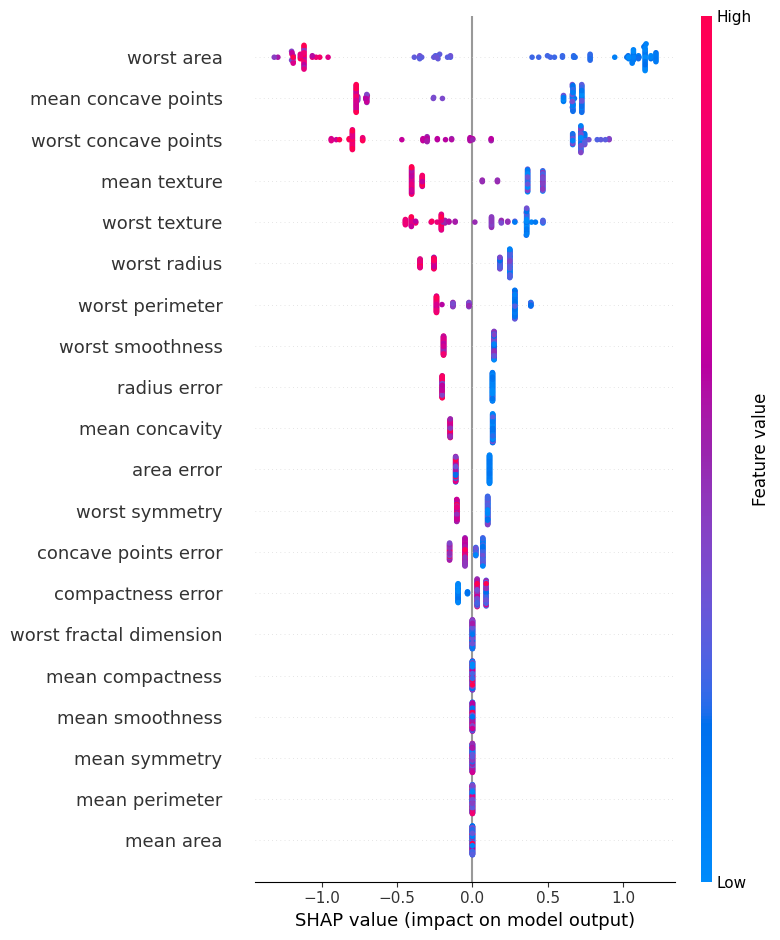

In [84]:
# Gera o explicador e os valores SHAP que serão utilizados nos gráficos a seguir
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Gráfico SHAP
shap.summary_plot(shap_values, X_test)

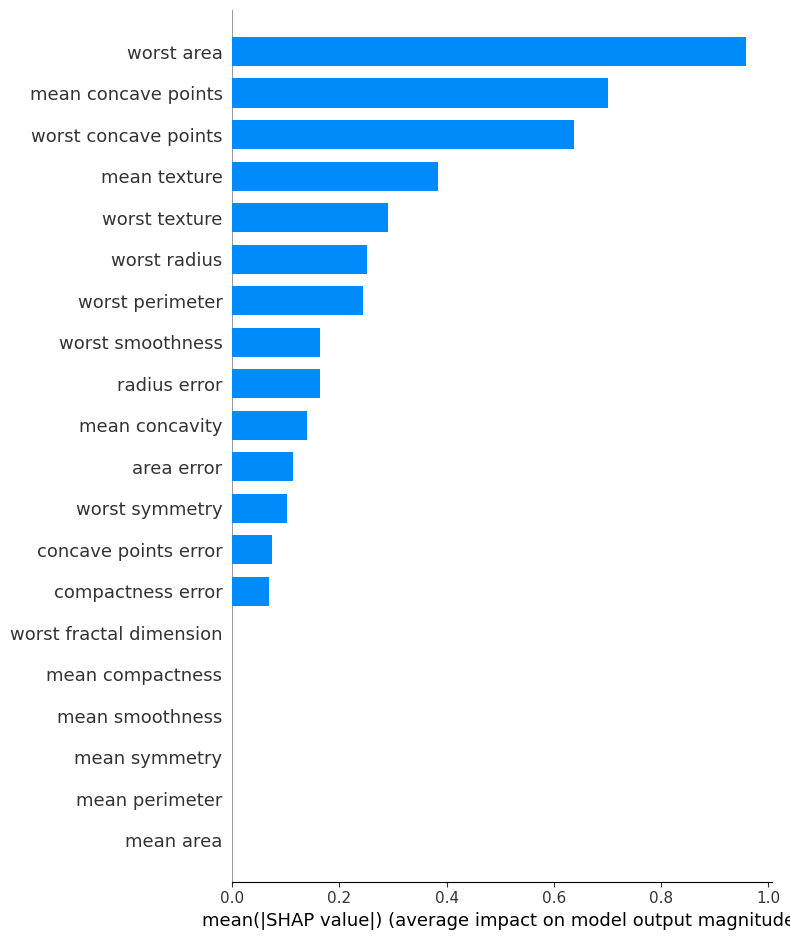

In [71]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

## Force Plot

Irei comentar o código nesta célula.

---

```i``` é o número da linha em **X_test**
```python
i = 0
```

---

O ```TreeExplainer``` é o explicador otimizado para modelos baseados em árvore (*Random Forest, XGBoost, LightGBM, etc*) Aqui, estou criando o objeto que calcula os valores *SHAP* a partir do meu modelo.

```python
explainer = shap.TreeExplainer(best_model)  
```

---

Apliquei o *explainer* sem ```.shap_values```, retornando um objeto *Explanation*
```python
shap_values = explainer(X_test)
```

---

Prepara o notebook para os gráficos interativos do *SHAP*
```python
shap.initjs()
```

---

Gera um ```gráfico de força```(*force plot*) interativo, mostrando como cada variável influenciou a predição da amostra definida em ```i```.
```python
shap.force_plot(explainer.expected_value,  # valor médio de saída do modelo
                shap_values[i].values,     # contribuições individuais de cada variável para a amostra "i"
                X_test.iloc[i])            # sempre manter o "i" consistente
```

---

### Interpretação
- **Setas vermelhas**: variáveis que aumentam a probabilidade do resultado positivo, ou seja, empurra o modelo para ```benigno```
- **Setas Azuis**: variáveis que aumentam a proababilidade do resultado negativo, aqui, seria para o ```maligno```
- **Tamanho da Seta**: proporção de influência

In [139]:
i = 0

explainer = shap.TreeExplainer(best_model)  
shap_values = explainer(X_test)

shap.initjs()
shap.force_plot(explainer.expected_value,
                shap_values[i].values,
                X_test.iloc[i])

## Matriz de Confusão

É uma tabela que visualiza o desempenho de um algoritmo de classificação, mostrando o número de previsões corretas e incorretas para cada categoria. 

- **Verdadeiros Positivos** (VP): O modelo previu corretamente que o paciente tem câncer.
- **Verdadeiros Negativos** (VN): O modelo previu corretamente que o paciente não tem câncer.
- **Falsos Positivos** (FP): O modelo previu que o paciente tem câncer, mas não realidade não tem. São os "*falsos alarmes*".
- **Falsos Negativos** (FN): O modelo previu que o paciente não tem câncer, mas na verdade tem. É o erro mais crítico em um contexto clínico, pois representa um diagnóstico perdido..

O meu objetivo principal é minimizar o número de ```Falsos Negativos``` (FN), garantindo que o maior número possível de pacientes com câncer seja idenfiticado corretamente

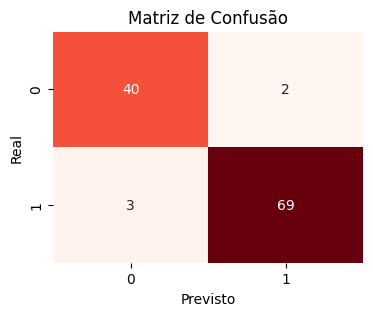

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Reds', cbar = False)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

## 1. Matriz de Confusão

|               | Previsto 0 | Previsto 1 |
|---------------|------------|------------|
| **Real 0**    | 40         | 2          |
| **Real 1**    | 3          | 69         |

**Classe 0 (sem câncer):**

- **Verdadeiros Negativos (VN)** = 40 → pacientes saudáveis corretamente classificados.  
- **Falsos Positivos (FP)** = 2 → pacientes saudáveis classificados como com câncer (falsos alarmes).

**Classe 1 (com câncer):**

- **Verdadeiros Positivos (VP)** = 69 → pacientes com câncer corretamente identificados.  
- **Falsos Negativos (FN)** = 3 → pacientes com câncer não identificados pelo modelo (erros críticos).

**Análise:**

- O modelo apresenta altíssima acurácia, com apenas 5 erros em 114 observações.  
- O **recall** da classe positiva (câncer) é muito alto:  
$$
  Recall = \frac{VP}{VP + FN} = \frac{69}{69 + 3} \approx 0.96
$$
  → 96% dos casos de câncer são identificados, o que é excelente clinicamente.  
- Poucos **falsos positivos** (2), então o modelo também mantém boa **precisão**.

---

## Curva ROC

É um gráfico que ilustra o desempenho de um modelo de classificação em diferentes limiares de decisão. Ela plota a taxa de ```Verdadeiros Positivos``` (VP) versus a taxa de ```Falsos Positivos``` (FP) à medida que o limiar de classificação é variado.

- **Eixo Y** (Verdadeiro Positivo/Recall/Sensibilidade): Representa a proporção de pacientes com câncer que foram corretamente identificados pelo modelo.
- **Eixo X** (Falso Positivo): Representa a proporção de pacientes saudáveis que foram erroneamente classificados com câncer.

### Métrica principal: Área Sob a Curva (AUC)
- **AUC = 1.0**: O modelo tem a capacidade perfeita de distinguir entre as classes.
- **AUC = 0.5**: O modelo tem o mesmo desempenho que um classificador aleatório.
- **AUC > 0.5**: O modelo tem um desempenho melhor que o de um classificador aleatório.

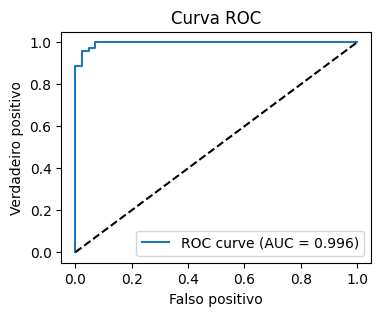

In [33]:
# Curva ROC

roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize = (4,3))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Falso positivo')
plt.ylabel('Verdadeiro positivo')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

## 2. Curva ROC

O gráfico mostra **Verdadeiros Positivos (Recall)** vs **Falsos Positivos**, com a curva muito próxima do canto superior esquerdo.

- **AUC = 0.994** → praticamente perfeita separação entre pacientes com e sem câncer.

**Análise:**

- O modelo consegue diferenciar quase todos os casos corretamente.  
- A proximidade da curva do canto superior esquerdo indica **alta sensibilidade** e **baixo risco de falsos negativos**, crítico em diagnóstico de câncer.  
- A linha pontilhada (diagonal) representa o classificador aleatório; a curva azul está muito acima, confirmando performance excelente.

---


## ✅ Conclusão Integrada

O modelo **XGBoost** é extremamente eficaz neste dataset:

- **Recall alto para casos de câncer** → segurança clínica.  
- **Baixo número de falsos positivos** → minimiza alarmes desnecessários.  
- **AUC quase 1** → forte separação das classes.

> Pode ser considerado confiável para apoio à triagem clínica, mantendo atenção à necessidade de validação em datasets externos antes de uso real.